In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd
import matplotlib as mpl

In [3]:
df = pd.read_excel('practica8.xlsx', sheet_name='Tarea 1')

BMagneticField = df["B (mT)"].to_numpy()
datay = BMagneticField / 1000
deltaBMagneticField = df["Error B"].to_numpy()
dataDeltaY = deltaBMagneticField / 1000
ICurrent = df["I (A)"].to_numpy()
datax = ICurrent
deltaICurrent = np.array([0.01 for i in range(len(ICurrent))]) #TODO Revisar el error!
dataDeltaX = deltaICurrent

In [4]:
def lineal(x, A, B):
    return A * x + B

In [7]:
popt, pcov = sp.optimize.curve_fit(lineal, datax, datay, sigma=dataDeltaY, absolute_sigma=True)

y_pred = lineal(datax, *popt)
r = datay - y_pred
chisq = sum((r / dataDeltaY) ** 2)
chisqRed = chisq / (len(datax)-1)

mediax = np.mean(datax)
mediay = np.mean(datay)
mediaxy = np.mean(datax*datay)
sigmax = np.std(datax)
sigmay = np.std(datay)

coefPearson = (mediaxy-mediax*mediay)/(sigmax*sigmay)

print("Chisq = ", chisqRed)
print("r = ", coefPearson)
print("R^2 = ", coefPearson**2)
print("pendiente = ", popt[0],"pm" , np.sqrt(pcov[0,0]))
print("ordenada = ", popt[1],"pm" , np.sqrt(pcov[1,1]))

Chisq =  1250.4124149061333
r =  0.9991129080846033
R^2 =  0.998226603101273
pendiente =  0.09803194819001608 pm 2.2140229260312098e-05
ordenada =  7.515361300899675e-06 pm 5.317350927321552e-06


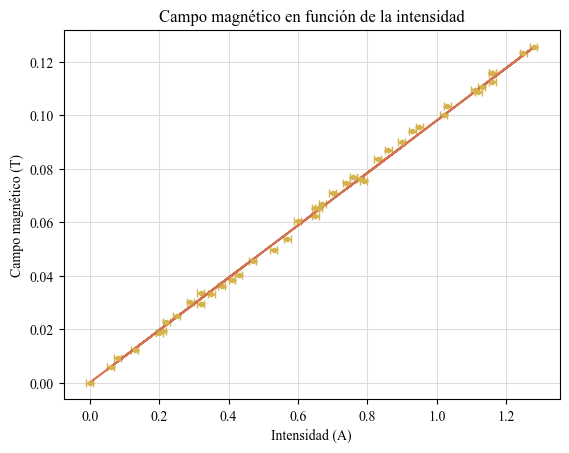

In [6]:
mpl.rcParams['font.family'] = 'Times New Roman'

plt.errorbar(datax, datay, color = "#d5B24b", yerr = dataDeltaY, xerr = dataDeltaX, ls="none", marker=".", elinewidth=1, capsize=3)
plt.plot(datax, lineal(datax, *popt), color = "#d17351")

plt.grid(color = "#dddddd")
plt.title("Campo magnético en función de la intensidad")
plt.xlabel("Intensidad (A)")
plt.ylabel("Campo magnético (T)")

plt.savefig("fitalex.png", dpi = 300)
plt.show()